# Fine-Tuning Qwen2.5-VL for Multimodal Metaphor Generation

This notebook demonstrates the fine-tuning of a Qwen2.5-VL model on the MultiMM dataset for generating multimodal metaphors in advertisements. The model learns to identify the 'vehicle' (visual element) and 'target' (concept) in metaphorical images.

## Overview
- **Dataset**: MultiMM (Multimodal Metaphor) dataset with advertisement images and metaphor labels.
- **Model**: Qwen2.5-VL-7B-Instruct with LoRA fine-tuning for efficiency.
- **Task**: Given an image, generate labels in the format "Vehicle: X | Target: Y".
- **Evaluation**: SBERT-based similarity scoring for metaphor components.

## Data Loading and Exploration

Load the MultiMM dataset from Excel and perform basic exploratory data analysis. The dataset contains advertisement images with metaphor annotations.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
"""
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
"""
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

import random
import json
from collections import Counter
import pprint

from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
import torch
from PIL import Image
from IPython.display import Image as DisplayImage, display
import requests
from io import BytesIO
import re

In [ ]:
#load dataset + basic eda

username = 'your_username_here'  # replace with your Kaggle username

multimm_path = f'/kaggle/input/datasets/{username}/multimm/EN.xlsx'

df = pd.read_excel(multimm_path)

print(len(df))

sample_df = df.sample(n=500, random_state=42)
print(sample_df.head())
print(sample_df.info())


4064
        Pic_id                                               Text  Unnamed: 2  \
2378  2379.jpg  if it happens once.it could happen again.nstop...           0   
2420  2421.jpg  elizabeth arden.nchoose for you the rare jragr...           0   
1940  1941.jpg                                  crlories crushed.           1   
1592  1593.jpg  DON’T ACT LIKE JOE PESCI.  \nNO OFFENSE JOE PE...           0   
2283  2284.jpg  light.a proud sponsor of the san francisco gia...           0   

     Target Source  SentimentCategory  
2378    NaN    NaN                  1  
2420    NaN    NaN                  1  
1940   cake   dirt                  1  
1592    NaN    NaN                  0  
2283    NaN    NaN                  0  
<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 2378 to 486
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Pic_id             500 non-null    object
 1   Text               4

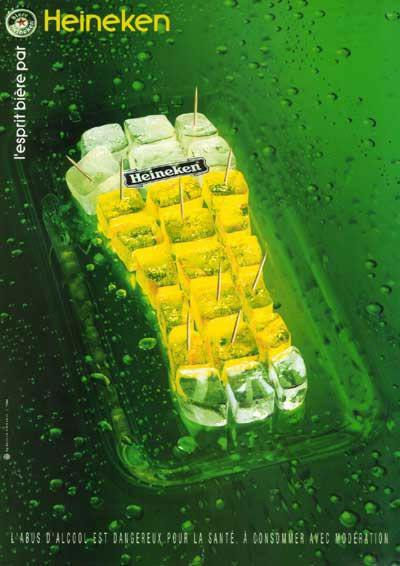

In [ ]:
# load images
multimm_images_path = f'/kaggle/input/datasets/{username}/multimm-images/imgs_EN/'

def generate_multimm_image(pic_id):
    return Image.open(multimm_images_path + pic_id)

#sample image
img = generate_multimm_image("1.jpg")
img

## Model Setup

Load the pre-trained Qwen2.5-VL model in 4-bit quantization to reduce memory usage. This model can process both text and images for multimodal tasks.

In [ ]:
# 1. Load the processor and the BASE model in 4-bit quantization
# if ImportError run in console: pip install -U bitsandbytes>=0.46.1
model_id = "Qwen/Qwen2.5-VL-7B-Instruct"
# Set max_pixels to avoid the "Vision Token Explosion"
# Qwen2.5-VL will automatically upscale small images if you don't stop it. Might lead to Out of memory error
min_pixels = 256 * 28 * 28
max_pixels = 512 * 28 * 28
processor = AutoProcessor.from_pretrained(model_id, min_pixels=min_pixels, max_pixels=max_pixels)

# 1. Define the quantization configuration (4-bit to save memory)
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

# 2. Load the model with the config
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=quantization_config, # Pass the config here
    device_map="auto",
    torch_dtype=torch.float16,
    trust_remote_code=True
)

## Sample Inference

Test the base model on a sample image to see its initial performance on metaphor analysis before fine-tuning.

In [ ]:
# sample chatbot usage

# Prepare the input
raw_image = generate_multimm_image("1.jpg")
system_prompt = (
    "You are an expert in multimodal metaphor analysis. "
    "Label the visual 'vehicle' in the image and the 'target' concept it represents. Generate your output in this format: 'Vehicle: vehicle | Target: target'"
)
messages = [
    {"role": "system", "content": [{"type": "text", "text": system_prompt}]},
    {
        "role": "user",
        "content": [
            {"type": "image", "image": raw_image},
            {"type": "text", "text": "State the metaphor in this advertisement"},
        ],
    }
]

# Process and Generate
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = processor(text=[text], images=[raw_image], return_tensors="pt").to("cuda")

generated_ids = model.generate(**inputs, max_new_tokens=128)
output_text = processor.batch_decode(generated_ids, skip_special_tokens=True)

print(output_text[0])

## Data Preprocessing

Format the metaphor labels and split the dataset into train/validation/test sets (80/10/10). Load the SBERT model for evaluation scoring.

In [4]:
# preprocess dataset
def format_metaphor_label(row):
    # Example output: "Vehicle: a lecture | Target: complaint"
    # ignore if any entry is null or empty
    source = str(row['Source'])
    target = str(row['Target'])
    if source == "nan" or target == "nan":
        return None
    return f"Vehicle: {source} | Target: {target}"
# Apply this to your dataframe before converting to a Hugging Face Dataset
df['formatted_label'] = df.apply(format_metaphor_label, axis=1)
df = df[df['formatted_label'].notnull()]

print(len(df))
print(df.iloc[0])

# Split 80/10/10 as per research paper
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print((len(train_df), len(val_df), len(test_df)))

2188
Pic_id                                      1.jpg
Text                                     heineken
Unnamed: 2                                      1
Target                                      glass
Source                                        ice
SentimentCategory                               0
formatted_label      Vehicle: ice | Target: glass
Name: 0, dtype: object
(1750, 219, 219)


In [5]:
# load sbert: Load a lightweight, high-quality SBERT model
from sentence_transformers import SentenceTransformer, util
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Evaluation Metrics

Define the scoring function using SBERT to compute semantic similarity between predicted and ground-truth vehicle/target pairs. This provides a more nuanced evaluation than exact string matching.

In [6]:
def compute_single_score(pred, gt_v, gt_t, sbert_model):
    # Case A: Model followed the structure
    if "Vehicle:" in pred and "Target:" in pred:
        try:
            p_v = pred.split("Target:")[0].replace("Vehicle:", "").strip("|").strip()
            p_t = pred.split("Target:")[1].strip()
            
            emb_pv = sbert_model.encode(p_v, convert_to_tensor=True)
            emb_gv = sbert_model.encode(gt_v, convert_to_tensor=True)
            emb_pt = sbert_model.encode(p_t, convert_to_tensor=True)
            emb_gt = sbert_model.encode(gt_t, convert_to_tensor=True)
            
            v_sim = util.cos_sim(emb_pv, emb_gv).item()
            t_sim = util.cos_sim(emb_pt, emb_gt).item()
            return (v_sim * 0.4) + (t_sim * 0.6)
        except:
            pass # Fall back to paragraph mode if split fails
            
    # Case B: Model gave a paragraph or weird format
    emb_p = sbert_model.encode(pred, convert_to_tensor=True)
    emb_gt = sbert_model.encode(gt_t, convert_to_tensor=True)
    return util.cos_sim(emb_p, emb_gt).item()

## Training Preparation

Prepare training samples by loading images and formatting conversations. Define the collate function for batching multimodal data with proper label masking.

In [ ]:
# training preparation
system_prompt = (
    "You are an expert in multimodal metaphor analysis. "
    "Label the visual 'vehicle' in the image and the 'target' concept it represents. Generate your output in this format: 'Vehicle: vehicle | Target: target'"
)

def prepare_training_sample(row):
    try:
        # 1. Generate the PIL image
        image = generate_multimm_image(row['Pic_id'])

        if image is None:
            return None

        # 2. THE FIX: Force the image to load into memory to check for truncation
        # This is where the OSError: "image file is truncated" happens
        image.load()
        
        # 2. Return a dict with explicit keys
        return {
            "image": image, # Add this dedicated key!
            "formatted_label": row['formatted_label'],
            "messages": [
                {"role": "system", "content": [{"type": "text", "text": system_prompt}]},
                {"role": "user", "content": [
                    {"type": "image", "image": image}, 
                    {"type": "text", "text": "Analyze the metaphor."}
                ]},
                {"role": "assistant", "content": [{"type": "text", "text": row['formatted_label']}]}
            ]
        }
    except (OSError, Exception) as e:
        # If the image is truncated or corrupted, we skip this row entirely
        print(f"Skipping corrupted image {row['Pic_id']}: {e}")
        return None

def collocate_fn(examples):
    # 1. Prepare texts (full conversation including response)
    texts = []
    for example in examples:
        prompt = f"<|im_start|>system\n{system_prompt}<|im_end|>\n"
        prompt += f"<|im_start|>user\n<|vision_start|><|image_pad|><|vision_end|>Analyze this metaphor.<|im_end|>\n"
        prompt += f"<|im_start|>assistant\n{example['formatted_label']}<|im_end|>"
        texts.append(prompt)

    images = [example["image"] for example in examples]

    # 2. Tokenize full batch
    batch = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True
    )
    
    # 3. Prepare labels: mask prompt tokens to -100
    labels = batch["input_ids"].clone()
    assistant_header = processor.tokenizer.encode("<|im_start|>assistant\n", add_special_tokens=False)
    header_len = len(assistant_header)
    
    for i in range(labels.size(0)):
        tokens = labels[i].tolist()
        found_idx = -1
        for idx in range(len(tokens) - header_len):
            if tokens[idx : idx + header_len] == assistant_header:
                found_idx = idx + header_len
                break
        
        if found_idx != -1:
            # Calculate actual sequence start (accounting for left padding)
            seq_len = batch["attention_mask"][i].sum().item()
            seq_start = labels.size(1) - seq_len
            # Mask from sequence start to assistant response start
            labels[i, seq_start:found_idx] = -100
        
        # Mask padding tokens
        labels[i, batch["attention_mask"][i] == 0] = -100
    
    batch["labels"] = labels
    return batch

## Training Metrics

Define the compute_metrics function for evaluation during training. This function decodes predictions and computes SBERT scores.

In [ ]:
def compute_metrics(eval_preds):
    preds, labels = eval_preds

    # Clean up labels (replace -100 with pad_id)
    labels = np.where(labels != -100, labels, processor.tokenizer.pad_token_id)

    # Ensure we have a valid pad token id (non-negative)
    pad_id = processor.tokenizer.pad_token_id
    if pad_id is None or pad_id < 0:
        pad_id = processor.tokenizer.eos_token_id

    # Replace any negative/out-of-range token ids with a valid padding id
    preds = np.where(preds < 0, pad_id, preds)
    labels = np.where(labels < 0, pad_id, labels)
    
    # Decode
    # clean_up_tokenization_spaces=True helps SBERT get a "cleaner" string
    decoded_preds = processor.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = processor.batch_decode(labels, skip_special_tokens=True)

    scores = []
    for pred, label in zip(decoded_preds, decoded_labels):
        # Extract only the text after the final "assistant" header
        p_clean = pred.split("assistant")[-1].strip()
        l_clean = label.split("assistant")[-1].strip()
        
        # Further trim if the model rambles after the Target
        # This keeps only the 'Vehicle: X | Target: Y' part
        p_clean = p_clean.split("\n")[0].split("analyzer")[-1].strip()

        # debug
        #print(f"DEBUG -> PRED: '{p_clean}' | LABEL: '{l_clean}'") # <--- ADD THIS
        
        try:
            # 🛡️ PROTECT AGAINST FORMAT ERRORS
            if "|" not in l_clean:
                continue
                
            gt_parts = l_clean.split("|")
            # Ensure we don't crash if label is malformed
            gt_source = gt_parts[0].replace("Vehicle:", "").strip() if len(gt_parts) > 0 else ""
            gt_target = gt_parts[1].replace("Target:", "").strip() if len(gt_parts) > 1 else ""
            
            # If ground truth is empty for some reason, skip
            if not gt_source or not gt_target:
                continue

            score = compute_single_score(p_clean, gt_source, gt_target, sbert_model)
            scores.append(score)
        except Exception as e:
            # During a sprint, we just ignore bad samples and keep moving
            print(f"Skipping a sample due to error: {e}")
            continue

    # Return 0.0 if everything failed, otherwise return average
    return {"sbert_metaphor_score": np.mean(scores) if scores else 0.0}

## Model Training

Set up LoRA configuration and train the model using the Seq2SeqTrainer. The training uses a small validation subset for efficiency.

In [ ]:
# training
from datasets import Dataset

# Convert your training DataFrame and filter out Nones in one go
train_list = [s for s in [prepare_training_sample(row) for _, row in train_df.iterrows()] if s is not None]
# Convert your list of dicts into a proper Hugging Face Dataset
train_dataset = Dataset.from_list(train_list)
# Convert your validation DataFrame into a proper Hugging Face Dataset
val_list = [s for s in [prepare_training_sample(row) for _, row in val_df.iterrows()] if s is not None]
val_dataset = Dataset.from_list(val_list)
# val small version
# 1. Shuffle the dataset with a seed for reproducibility 
# 2. Select the first 50 samples
val_dataset_small = val_dataset.shuffle(seed=42).select(range(min(50, len(val_dataset))))

from peft import LoraConfig, get_peft_model

peft_config = LoraConfig(
    r=16,                       # Rank: higher means more capacity, try 16 or 32
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"], # Target attention layers
    lora_dropout=0.05,
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, GenerationConfig

# Find the token ID for the newline or the end of the thought
stop_tokens = ["\n", "<|im_end|>", "user", "assistant"]
stop_token_ids = [processor.tokenizer.encode(t, add_special_tokens=False)[0] for t in stop_tokens]

# Define the generation rules clearly
generation_config = GenerationConfig(
    max_new_tokens=40,     # Generate up to 40 tokens regardless of input size
    do_sample=False,       # Greedy search for speed and consistency
    pad_token_id=processor.tokenizer.pad_token_id,
    eos_token_id=stop_token_ids + [processor.tokenizer.eos_token_id],
)

training_args = Seq2SeqTrainingArguments(
    output_dir="./qwen2.5-vl-metaphor",
    per_device_train_batch_size=1,   # Keep small for VRAM
    gradient_accumulation_steps=8,   # Effective batch size of 8
    learning_rate=2e-4,              # Standard for LoRA
    num_train_epochs=3,
    eval_strategy="steps",
    eval_steps=0.083333333,          # Evaluate every: epochs * 0.083333333
    
    save_strategy="steps",
    save_steps=0.083333333,
    save_total_limit=1,
    
    logging_steps=20,
    predict_with_generate=True,      # This triggers the generation for SBERT
    #generation_max_length=128,
    generation_config=generation_config,
    fp16=True,                       # Use mixed precision for speed
    remove_unused_columns=False,     # Important for multimodal
    # ADD: This ensures images are handled correctly in the backend
    dataloader_pin_memory=True
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset_small,    # small version CHANGE BACK ONCE FIX
    data_collator=collocate_fn,        # Use the collator defined earlier
    compute_metrics=compute_metrics, # Uses your SBERT logic
)

# Crucial fix for generation
processor.tokenizer.padding_side = "left"
processor.tokenizer.pad_token = processor.tokenizer.eos_token

trainer.train()

"""
Step | Training Loss | Validation Loss
55 | 1.143293 | 1.264671
110 | 1.198372 | 1.236676
165 | 1.054378 | 1.252621
220 | 1.063116 | 1.222719
275 (new epoch) | 0.861308 | 1.261805
330 | 0.993406 | 1.214470
"""

## Save Trained Model

Save the LoRA adapters and processor for later inference.

In [ ]:
# save modified model

# Save lora weights to a local folder
trainer.save_model("./qwen2.5-vl-metaphor-lora-save")

# Save the processor (you'll need this for inference later!)
processor.save_pretrained("./qwen2.5-vl-metaphor-lora-save")

## Load Trained Model

Load the fine-tuned model with LoRA adapters for inference.

In [7]:
# import model with lora
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from peft import PeftModel

model_id = "Qwen/Qwen2.5-VL-7B-Instruct"
adapter_path = "./qwen2.5-vl-metaphor-lora-save"

# 1. Load Processor from your SAVED folder (to get your templates/settings)
# If the folder doesn't exist yet, use model_id
min_pixels = 256 * 28 * 28
max_pixels = 512 * 28 * 28
processor = AutoProcessor.from_pretrained(adapter_path, trust_remote_code=True, min_pixels=min_pixels, max_pixels=max_pixels)

# 2. Configure 4-bit Quantization
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

# 3. Load Base Model in 4-bit
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map="auto",
    torch_dtype=torch.float16,
    trust_remote_code=True
)

# 4. Load your LoRA Adapter onto the 4-bit base
model = PeftModel.from_pretrained(model, adapter_path)

# 5. Final Setup
model.eval()
print("Consistent 4-bit + LoRA Model loaded successfully!")

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Consistent 4-bit + LoRA Model loaded successfully!


## Final Evaluation

Evaluate the fine-tuned model on the test set. Compare performance to baseline (untrained model score: 0.3118, trained model score: 0.4837), showing improvement in metaphor analysis.

In [ ]:
# FINAL TEST
import gc
import torch
import pandas as pd
from tqdm import tqdm
from sentence_transformers import util

# 1. Ensure model is in inference mode
model.eval()

results = []
all_scores = []

# Define your task-specific prompt
system_prompt = (
    "You are an expert in multimodal metaphor analysis. "
    "Label the visual 'vehicle' in the image and the 'target' concept it represents. Generate your output in this format: 'Vehicle: vehicle | Target: target'"
)

print(f"Evaluating {len(test_df)} samples...")

for i, row in tqdm(test_df.iterrows(), total=len(test_df)):
    image = generate_multimm_image(row['Pic_id'])
    gt_label = row['formatted_label'] # "Vehicle: lecture | Target: complaint"
    gt_source = str(row['Source'])
    gt_target = str(row['Target'])
    
    # Construct Message
    messages = [
        {"role": "system", "content": [{"type": "text", "text": system_prompt}]},
        {"role": "user", "content": [{"type": "image", "image": image}, {"type": "text", "text": "Analyze the metaphor."}]}
    ]
    
    # Process
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt").to("cuda")

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs, 
            max_new_tokens=128, # Metaphors need a bit more room than captions
            do_sample=False 
        )
    
    # Decode
    raw_pred = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    cleaned_pred = raw_pred.split("assistant")[-1].strip() if "assistant" in raw_pred else raw_pred
    
    # debug output (commented out for presentation)
    # print("|id:", row['Pic_id'])
    # print("|pred", cleaned_pred)
    # print("|gt:", gt_label + "|")
    # print()
    
    # 2. Adaptive SBERT Score
    # We compare the prediction to the structured ground truth
    score = compute_single_score(cleaned_pred, gt_source, gt_target, sbert_model)
    
    all_scores.append(score)
    results.append({
        "image_id": row.get('Image_ID', i),
        "prediction": cleaned_pred,
        "ground_truth": gt_label,
        "score": score
    })
    
    # 3. Memory Safety
    del inputs, generated_ids
    gc.collect()
    torch.cuda.empty_cache()

# Final Report
avg_sbert = sum(all_scores) / len(all_scores)
print(f"\n--- MultiMM Metaphor Evaluation ---")
print(f"Average Metaphor Similarity Score: {avg_sbert:.4f}")

Evaluating 219 samples...


  0%|          | 0/219 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


|id: 3080.jpg
|pred Vehicle: sheep | Target: skier
|gt: Vehicle: snow | Target: pasture|



  0%|          | 1/219 [00:04<15:55,  4.38s/it]

|id: 523.jpg
|pred Vehicle: pyramid | Target: bear
|gt: Vehicle: pyramid | Target: Toblerone|



...

|id: 540.jpg
|pred Vehicle: beach | Target: blender
|gt: Vehicle: lobster | Target: knife|



100%|█████████▉| 218/219 [07:56<00:02,  2.27s/it]

|id: 2223.jpg
|pred Vehicle: hair | Target: chewing gum
|gt: Vehicle: chiclets | Target: hair|



100%|██████████| 219/219 [07:59<00:00,  2.19s/it]


--- MultiMM Metaphor Evaluation ---
Average Metaphor Similarity Score: 0.4837


## What this eval means:

The fine-tuned Qwen2.5-VL model shows improved performance on multimodal metaphor analysis, with the SBERT score increasing from 0.3118 (baseline) to 0.4837 (trained). This demonstrates the model's ability to learn the specific labeling style of the MultiMM dataset.

**Key Takeaways:**
- LoRA fine-tuning enables efficient adaptation of large multimodal models.
- SBERT-based evaluation provides semantic-aware scoring for metaphor components.
- Proper data preprocessing and batching are crucial for multimodal training.

## Using the finetuned Qwen2.5-VL model for inference

In [ ]:
# replace memecap metaphors using trained model on multimm dataset

import json
import requests
from PIL import Image
from io import BytesIO
# Load the memecap dataset
memecap_path = f'/kaggle/input/datasets/{username}/memecap-images/trainval_image/'
def generate_memecap_image(f):
    return Image.open(os.path.join(memecap_path, f)).convert("RGB")

# 2. Load or Initialize the mapping
# We use a dictionary for the loop because it's much faster for lookups/updates
try:
    with open('updated_memecap.json', 'r', encoding='utf-8') as f:
        updated_memecap = json.load(f)
    total = len(updated_memecap)
    print(f"Loaded existing dataset with {len(updated_memecap)} entries.")
    # Count how many values are not No
    non_null = sum(1 for v in updated_memecap.values() if v is not None)
    # Count how many are still None
    null_count = total - non_null
    print(f"📊 Progress Report:")
    print(f"Total Images:    {total}")
    print(f"Processed:       {non_null} ({(non_null/total)*100:.1f}%)")
    print(f"Remaining:       {null_count}")
    
except (FileNotFoundError, json.JSONDecodeError):
    print("Initializing new dataset mapping...")
    updated_memecap = {}
    for filename in os.listdir(memecap_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            updated_memecap[filename] = None

# 3. Inference Loop
system_prompt = (
    "You are an expert in multimodal metaphor analysis. "
    "Label the visual 'vehicle' in the image and the 'target' concept it represents. "
    "Generate your output in this format: 'Vehicle: vehicle | Target: target'"
)

# Convert to list for tqdm and slicing
items = list(updated_memecap.items())
limit = 9999  # Your debug limit
count = 0

from tqdm import tqdm
for k, v in tqdm(items, desc="Processing Memes"):
    if v is not None:  # Skip already processed
        continue
    if count >= limit:
        break
        
    try:
        img = generate_memecap_image(k)
        
        # Prepare ChatML format
        messages = [
            {"role": "system", "content": [{"type": "text", "text": system_prompt}]},
            {"role": "user", "content": [
                {"type": "image", "image": img},
                {"type": "text", "text": "Analyze the metaphor."}
            ]}
        ]
        
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        
        # Process inputs with pixel constraints to prevent OOM
        inputs = processor(
            text=[text], 
            images=[img], 
            return_tensors="pt"
        ).to("cuda")
        
        # Inference
        input_len = inputs.input_ids.shape[1]
        with torch.no_grad():
            generated_ids = model.generate(
                **inputs, 
                max_new_tokens=50,
                do_sample=False
            )
        
        # Decode only the new response tokens
        output_text = processor.batch_decode(
            generated_ids[:, input_len:], 
            skip_special_tokens=True
        )[0].strip()

        # Further trim if the model rambles after the Target
        # This keeps only the 'Vehicle: X | Target: Y' part
        output_text = output_text.split("\n")[0].strip()

        updated_memecap[k] = output_text
        count += 1
        
    except Exception as e:
        print(f"Error processing {k}: {e}")

# 4. Save the updated dataset
with open('updated_memecap.json', 'w', encoding='utf-8') as f:
    json.dump(updated_memecap, f, indent=4)
    print("\nFile saved successfully.")

### This updates the memecap dataset with Qwen metaphors

In [ ]:
import json
def update_metaphors(memecap_file, trainval_file, output_file):
    # Load the memecap data
    with open(memecap_file, 'r') as f:
        memecap_data = json.load(f)

    # Load the trainval data
    with open(trainval_file, 'r') as f:
        trainval_data = json.load(f)

    # Create a mapping from post_id to metaphors and meanings
    post_id_to_metaphors = {}
    for k, v in memecap_data.items():
        post_id = k.split('_')[1].split('.')[0]  # Extract post_id from filename
        vehicle = v.split('|')[0].strip().split(':')[1].strip()  # Extract vehicle
        target = v.split('|')[1].strip().split(':')[1].strip()  # Extract target
        post_id_to_metaphors[post_id] = (vehicle, target)

    # Update the metaphors in the trainval data
    for item in trainval_data:
        post_id = item['post_id']
        if post_id in post_id_to_metaphors:
            vehicle, target = post_id_to_metaphors[post_id]
            item['metaphors'] = [{'metaphor': vehicle, 'meaning': target}]

    # Save the updated data to a new JSON file
    with open(output_file, 'w') as f:
        json.dump(trainval_data, f, indent=4)
# Example usage
update_metaphors('updated_memecap.json', f'/kaggle/input/datasets/{username}/memes-trainval/memes-trainval.json', 'updated_memes-trainval.json')